<a href="https://colab.research.google.com/github/Divyaanshvats/PneumoVision/blob/main/CHEST_X_RAY_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip -q install kaggle grad-cam scikit-learn seaborn
#General Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#PyTorch import
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torchvision import models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#Reproducibility
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


#DEVICE THAT I WILL USE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("PROJECT: Chest X-Ray Pneumonia Classification")
print("=" * 60)

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"Device          : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version    : {torch.version.cuda}")

print("=" * 60)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PROJECT: Chest X-Ray Pneumonia Classification
PyTorch version : 2.11.0+cu128
Torchvision     : 0.26.0+cu128
Device          : cuda
GPU             : Tesla T4
CUDA version    : 12.8


In [3]:
# ============================================================
# CELL 2 — KAGGLE DATASET
# ============================================================

from google.colab import files

print("Upload your kaggle.json file")
uploaded = files.upload()

# Move Kaggle credentials into the correct location
os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \
    -p /content/

# Extract
!unzip -q /content/chest-xray-pneumonia.zip -d /content/chest_xray/

print("\nDataset downloaded and extracted.")

Upload your kaggle.json file


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:28<00:00, 85.4MB/s]


Dataset downloaded and extracted.


In [4]:
# ============================================================
# CELL 3 — DATASET VERIFICATION
# ============================================================

DATA_ROOT = "/content/chest_xray/chest_xray"
total_images_count = 0

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    print("-" * 40)

    for class_name in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(DATA_ROOT, split, class_name)

        count = len([
            f for f in os.listdir(path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        total_images_count += count
        print(f"{class_name:10s}: {count}")

print("\nDataset root:", DATA_ROOT)
print("Total number of images:", total_images_count)


TRAIN
----------------------------------------
NORMAL    : 1341
PNEUMONIA : 3875

VAL
----------------------------------------
NORMAL    : 8
PNEUMONIA : 8

TEST
----------------------------------------
NORMAL    : 234
PNEUMONIA : 390

Dataset root: /content/chest_xray/chest_xray
Total number of images: 5856


In [5]:
#THE DATA PIPELINE

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

IMG_SIZE=224
BATCH_SIZE=32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# different transforms
train_dataset = ImageFolder(
    os.path.join(DATA_ROOT, "train"),
    transform=train_transform
)

val_dataset = ImageFolder(
    os.path.join(DATA_ROOT, "val"),
    transform=eval_transform
)

test_dataset = ImageFolder(
    os.path.join(DATA_ROOT, "test"),
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_dataset.classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Training samples: 5216
Validation samples: 16
Test samples: 624


In [6]:

#DENSENET121 BASELINE TRAINING
weights=models.DenseNet121_Weights.DEFAULT
model=models.densenet121(weights=weights)

#We freeze the pre-trained feature so that we do not overfit the mode
#Also because our model is much smaller than ImageNet and if we train
#it on 121 layers then it might loose important pre-trained representation
#And of-course it will take longer time to run
for param in model.features.parameters():
  param.requires_grad=False

#Ours is binary classification hence 2 output(Pneumonia or Not)
num_features=model.classifier.in_features
model.classifier=nn.Linear(num_features,2)
model=model.to(DEVICE)

#Now crossentropyloss is for 2 class classification problem either normal
#or pneumonia. We do not have softmax since crossentropy internally handles
#log-softmax operation.
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.classifier.parameters(), lr=1e-3)

EPOCHS=5 #Now training aspect
for epochs in range(EPOCHS):
  model.train()
  train_loss=0.0
  train_correct=0
  train_total=0

  for images, labels in train_loader:
    images=images.to(DEVICE)
    labels=labels.to(DEVICE)

    #Training's important part starts here

    #Pytorch accumulates gradient by default so reset it before calculating new one
    optimizer.zero_grad()

    #Forward PASS
    outputs=model(images)
    #Backpropogation and LOSS Calculation
    loss=criterion(outputs, labels)
    loss.backward()

    #Update the weights
    optimizer.step()

    #Calculate the overall training loss
    train_loss+=loss.item()*images.size(0)
    predictions=outputs.argmax(dim=1)
    train_correct+=(predictions==labels).sum().item()
    train_total+=labels.size(0)

  train_loss=train_loss/train_total
  train_acc=train_correct/train_total

  #VALIDATION PART

  model.eval()

  val_loss=0.0
  val_correct=0.0
  val_total=0
  with torch.no_grad():
    for images, labels in val_loader:
      images=images.to(DEVICE)
      labels=labels.to(DEVICE)

      outputs=model(images)
      loss=criterion(outputs,labels)

      val_loss+=loss.item()*images.size(0)
      predictions=outputs.argmax(dim=1)
      val_correct+=(predictions==labels).sum().item()
      val_total+=labels.size(0)

  val_loss=val_loss/val_total
  val_acc=val_correct/val_total
  print(
        f"Epoch [{epochs+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 122MB/s]


Epoch [1/5] | Train Loss: 0.2985 | Train Acc: 0.8777 | Val Loss: 0.2666 | Val Acc: 1.0000
Epoch [2/5] | Train Loss: 0.1830 | Train Acc: 0.9287 | Val Loss: 0.1973 | Val Acc: 1.0000
Epoch [3/5] | Train Loss: 0.1637 | Train Acc: 0.9383 | Val Loss: 0.1602 | Val Acc: 1.0000
Epoch [4/5] | Train Loss: 0.1578 | Train Acc: 0.9369 | Val Loss: 0.1930 | Val Acc: 1.0000
Epoch [5/5] | Train Loss: 0.1359 | Train Acc: 0.9488 | Val Loss: 0.1874 | Val Acc: 0.9375


In [7]:
#DENSENET121 FINE TUNING

# ============================================================
# CELL 6 — DENSENET121 FINE-TUNING
# ============================================================

# Unfreeze the last dense block and final normalization layer
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

EPOCHS_FINE = 5

for epoch in range(EPOCHS_FINE):

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(
        f"Fine-tune Epoch [{epoch+1}/{EPOCHS_FINE}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Fine-tune Epoch [1/5] | Train Loss: 0.1243 | Train Acc: 0.9542 | Val Loss: 0.1760 | Val Acc: 0.9375
Fine-tune Epoch [2/5] | Train Loss: 0.1159 | Train Acc: 0.9563 | Val Loss: 0.2006 | Val Acc: 0.8750
Fine-tune Epoch [3/5] | Train Loss: 0.1015 | Train Acc: 0.9613 | Val Loss: 0.2629 | Val Acc: 0.8125
Fine-tune Epoch [4/5] | Train Loss: 0.0945 | Train Acc: 0.9663 | Val Loss: 0.2311 | Val Acc: 0.8750
Fine-tune Epoch [5/5] | Train Loss: 0.0878 | Train Acc: 0.9641 | Val Loss: 0.2398 | Val Acc: 0.8750


FINAL TEST SET RESULTS
Test samples : 624
Accuracy     : 0.8558
Precision    : 0.8205
Recall       : 0.9846
Specificity  : 0.6410
F1 Score     : 0.8951
ROC-AUC      : 0.9584

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.64      0.77       234
   PNEUMONIA       0.82      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.86      0.85       624



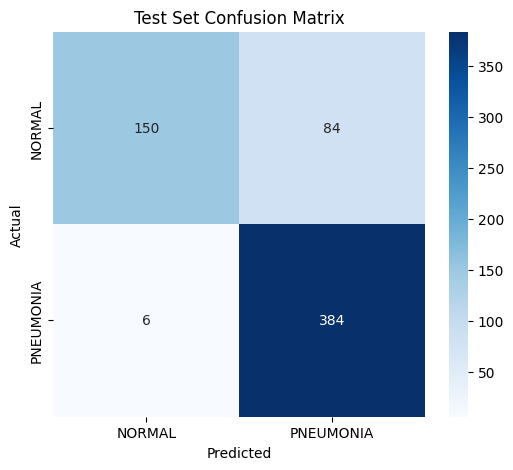

In [8]:
# ============================================================
# CELL 7 — FINAL TESTING ON TEST DATASET
# ============================================================

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]

        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

tn, fp, fn, tp = confusion_matrix(
    all_labels,
    all_predictions
).ravel()

specificity = tn / (tn + fp)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("=" * 50)
print("FINAL TEST SET RESULTS")
print("=" * 50)

print(f"Test samples : {len(all_labels)}")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")

plt.show()

In [9]:
# Find every ZIP and show its contents

for root, dirs, files in os.walk("/content/external_dataset"):
    for file in files:
        if file.lower().endswith(".zip"):
            zip_path = os.path.join(root, file)

            print("\n" + "=" * 80)
            print("ZIP:", zip_path)

            with zipfile.ZipFile(zip_path, "r") as z:
                names = z.namelist()

                print("Number of files:", len(names))
                print("First 20 entries:")

                for name in names[:20]:
                    print("  ", name)

In [10]:
# ============================================================
# FIX — EXTRACT MAIN EXTERNAL DATASET
# ============================================================

import zipfile
import os

EXTERNAL_MAIN_ZIP = "/content/Detection of Pneumonia Disease using Chest Radiogr.zip"
EXTERNAL_DEST_DIR = "/content/external_dataset"

os.makedirs(EXTERNAL_DEST_DIR, exist_ok=True)

with zipfile.ZipFile(EXTERNAL_MAIN_ZIP, "r") as z:
    z.extractall(EXTERNAL_DEST_DIR)

print(f"Extracted {EXTERNAL_MAIN_ZIP} to {EXTERNAL_DEST_DIR}")

# Verify contents (optional, can be removed after verification)
print("\nContents of extracted directory:")
for root, dirs, files in os.walk(EXTERNAL_DEST_DIR):
    for name in files:
        print(os.path.join(root, name))

Extracted /content/Detection of Pneumonia Disease using Chest Radiogr.zip to /content/external_dataset

Contents of extracted directory:
/content/external_dataset/Detection of Pneumonia Disease using Chest Radiogr/Chest_Radiograh Screeing (X-Ray).zip
/content/external_dataset/Detection of Pneumonia Disease using Chest Radiogr/NORMAL_Images.zip


In [11]:
# ============================================================
# FIX — EXTRACT EXTERNAL DATASET
# ============================================================

NORMAL_ZIP = "/content/external_dataset/Detection of Pneumonia Disease using Chest Radiogr/NORMAL_Images.zip"

PNEUMONIA_ZIP = "/content/external_dataset/Detection of Pneumonia Disease using Chest Radiogr/Chest_Radiograh Screeing (X-Ray).zip"

FINAL_ROOT = "/content/external_test"

# Clean the old empty folders
import shutil
import zipfile  # Added this import
import os       # Added this import for explicit dependency

if os.path.exists(FINAL_ROOT):
    shutil.rmtree(FINAL_ROOT)

os.makedirs(os.path.join(FINAL_ROOT, "NORMAL"))
os.makedirs(os.path.join(FINAL_ROOT, "PNEUMONIA"))

# Extract NORMAL
with zipfile.ZipFile(NORMAL_ZIP, "r") as z:
    for member in z.namelist():
        if member.lower().endswith((".jpg", ".jpeg", ".png")):
            filename = os.path.basename(member)

            with z.open(member) as source:
                with open(
                    os.path.join(FINAL_ROOT, "NORMAL", filename),
                    "wb"
                ) as target:
                    target.write(source.read())

# Extract PNEUMONIA
with zipfile.ZipFile(PNEUMONIA_ZIP, "r") as z:
    for member in z.namelist():
        if member.lower().endswith((".jpg", ".jpeg", ".png")):
            filename = os.path.basename(member)

            with z.open(member) as source:
                with open(
                    os.path.join(FINAL_ROOT, "PNEUMONIA", filename),
                    "wb"
                ) as target:
                    target.write(source.read())

print("Dataset prepared.")

Dataset prepared.


In [12]:
for class_name in ["NORMAL", "PNEUMONIA"]:

    path = os.path.join(FINAL_ROOT, class_name)

    count = len([
        f for f in os.listdir(path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"{class_name}: {count}")

NORMAL: 204
PNEUMONIA: 300


In [13]:
# ============================================================
# CELL 13 — EXTERNAL VALIDATION
# ============================================================

external_dataset = ImageFolder(
    FINAL_ROOT,
    transform=eval_transform
)

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", external_dataset.classes)
print("External samples:", len(external_dataset))

model.eval()

external_labels = []
external_predictions = []
external_probabilities = []

with torch.no_grad():

    for images, labels in external_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = outputs.argmax(dim=1)

        external_labels.extend(labels.numpy())
        external_predictions.extend(
            predictions.cpu().numpy()
        )
        external_probabilities.extend(
            probabilities.cpu().numpy()
        )

# Metrics
accuracy = accuracy_score(
    external_labels,
    external_predictions
)

precision = precision_score(
    external_labels,
    external_predictions
)

recall = recall_score(
    external_labels,
    external_predictions
)

f1 = f1_score(
    external_labels,
    external_predictions
)

roc_auc = roc_auc_score(
    external_labels,
    external_probabilities
)

tn, fp, fn, tp = confusion_matrix(
    external_labels,
    external_predictions
).ravel()

specificity = tn / (tn + fp)

print("\nEXTERNAL VALIDATION RESULTS")
print("=" * 45)

print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    external_labels,
    external_predictions
))

print("\nClassification Report:")
print(classification_report(
    external_labels,
    external_predictions,
    target_names=external_dataset.classes
))

Classes: ['NORMAL', 'PNEUMONIA']
External samples: 504

EXTERNAL VALIDATION RESULTS
Accuracy    : 0.6012
Precision   : 0.5996
Recall      : 0.9933
Specificity : 0.0245
F1 Score    : 0.7478
ROC-AUC     : 0.7411

Confusion Matrix:
[[  5 199]
 [  2 298]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.71      0.02      0.05       204
   PNEUMONIA       0.60      0.99      0.75       300

    accuracy                           0.60       504
   macro avg       0.66      0.51      0.40       504
weighted avg       0.65      0.60      0.46       504



In [14]:
# SAVE TRAINED MODEL

torch.save(
    model.state_dict(),
    "/content/densenet121_pneumonia.pth"
)

print("Model saved.")

Model saved.


### Run the Streamlit Application

To run the Streamlit app, we first need to save the code from the previous cell into a Python file. Then, we can execute this file using `streamlit run`. Since Streamlit runs as a web server, we'll use `ngrok` to create a public URL that allows you to access the app from your browser.

In [26]:
# Save the Streamlit app code to a Python file
app_code = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

DEVICE = torch.device("cpu")

CLASSES = ["NORMAL", "PNEUMONIA"]


# ------------------------------------------------------------
# IMAGE PREPROCESSING
# Same preprocessing used during evaluation
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

@st.cache_resource
def load_model():

    model = models.densenet121(weights=None)

    num_features = model.classifier.in_features

    model.classifier = nn.Linear(
        num_features,
        2
    )

    model.load_state_dict(
        torch.load(
            "densenet121_pneumonia.pth",
            map_location=DEVICE
        )
    )

    model.eval()

    return model


model = load_model()


# ------------------------------------------------------------
# STREAMLIT UI
# ------------------------------------------------------------

st.set_page_config(
    page_title="Pneumonia Detection",
    page_icon="🫁"
)

st.title("🫁 Chest X-Ray Pneumonia Detection")

st.write(
    "DenseNet121 Transfer Learning"
)

st.divider()


uploaded_file = st.file_uploader(
    "Upload a chest X-ray",
    type=["jpg", "jpeg", "png"]
)


# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Chest X-Ray",
        use_container_width=True
    )

    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[0]

        predicted_class = torch.argmax(
            probabilities
        ).item()

        confidence = probabilities[
            predicted_class
        ].item()

    st.divider()

    st.subheader("Prediction")

    st.write(
        f"**{CLASSES[predicted_class]}**"
    )

    st.write(
        f"Confidence: **{confidence:.2%}**"
    )

    st.progress(confidence)

    st.divider()

    st.caption(
        "For educational and research purposes only. "
        "This application is not a medical diagnostic tool."
    )
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("Streamlit app saved to app.py")

Streamlit app saved to app.py


In [27]:
from google.colab import userdata

# Install pyngrok to expose the Streamlit app
!pip install pyngrok

# Run the Streamlit app and expose it via ngrok
# This command will output a public URL you can click to access your app.
# It will keep running until you stop the cell execution.

from pyngrok import ngrok
import subprocess
import os

# Terminate any existing ngrok tunnels
ngrok.kill()

# Get your ngrok authtoken from Colab's Secrets Manager
# You can set this secret named 'NGROK_AUTH_TOKEN' in the '🔑 Secrets' tab on the left sidebar.
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Start Streamlit in the background
# The --server.enableCORS false and --server.enableXsrfProtection false are added for Colab compatibility.
streamlit_process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true", "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Open a ngrok tunnel to the Streamlit port
public_url = ngrok.connect(addr=8501, proto="http")
print(f"Streamlit App URL: {public_url}")

# You can view the logs for the Streamlit app if needed
# print("Streamlit server output:")
# for line in streamlit_process.stdout:
#    print(line.decode().strip())

Streamlit App URL: NgrokTunnel: "https://1389-34-139-222-208.ngrok-free.app" -> "http://localhost:8501"
